# MAT499/599 Project 1 - Fully Connected Neural Networks (PyTorch)

This notebook implements all required tasks from `Project_1.pdf` using object-oriented PyTorch code.


## Submission Notes

- File type requirement is satisfied: this is an `.ipynb` notebook.
- Seed is set for `random`, `numpy`, and `torch` in one place.
- The notebook uses reusable classes from `src/` (`data.py`, `model.py`, `loss.py`, `train.py`).
- For MAT499 keep `CLASS_SEED = 499`; for MAT599 change it to `599`.


In [41]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data import WineQualityData
from src.loss import MSERegressionLoss
from src.model import (
    LinearRegressionModel,
    SingleHiddenLayerNetwork,
    ThreeHiddenLayerNetwork,
    count_trainable_parameters,
)
from src.train import ExperimentRunner, SeedManager, TrainConfig

plt.style.use('seaborn-v0_8-whitegrid')


In [42]:
CLASS_SEED = 499
SeedManager.set_seed(CLASS_SEED)

dataset = WineQualityData()
features, targets = dataset.load_tensors(standardize=True)
input_dim = features.shape[1]

runner = ExperimentRunner(loss_fn=MSERegressionLoss())
base_config = TrainConfig(
    learning_rate=0.01,
    max_epochs=20000,
    convergence_window=50,
    convergence_decimals=4,
)

print(f'Seed: {CLASS_SEED}')
print(f'Features shape: {tuple(features.shape)}')
print(f'Target shape: {tuple(targets.shape)}')


Seed: 499
Features shape: (1599, 11)
Target shape: (1599,)


## Question 1

Fit and compare these three models with gradient descent (`lr = 0.01`):

1. Linear model
2. Single hidden layer neural network (12 neurons)
3. Three hidden layer neural network (12, 8, 4 neurons)

Also report parameter counts, plot loss vs epoch on one axis, and discuss convergence/minimum loss.


In [43]:
SeedManager.set_seed(CLASS_SEED)

q1_models = {
    'Linear Model': lambda: LinearRegressionModel(input_dim=input_dim),
    '1 Hidden Layer (12)': lambda: SingleHiddenLayerNetwork(input_dim=input_dim, hidden_dim=12),
    '3 Hidden Layers (12, 8, 4)': lambda: ThreeHiddenLayerNetwork(input_dim=input_dim, hidden_dims=(12, 8, 4)),
}

q1_results = {}
q1_parameter_counts = {}

for model_name, model_factory in q1_models.items():
    model = model_factory()
    q1_parameter_counts[model_name] = count_trainable_parameters(model)
    q1_results[model_name] = runner.train_model(
        model=model,
        features=features,
        targets=targets,
        config=base_config,
        model_name=model_name,
    )

q1_table = pd.DataFrame(
    {
        'Model': list(q1_results.keys()),
        'Parameters': [q1_parameter_counts[name] for name in q1_results],
        'Final Loss': [q1_results[name].final_loss for name in q1_results],
        'Epochs Run': [q1_results[name].epochs_run for name in q1_results],
        'Converged': [q1_results[name].converged for name in q1_results],
    }
)
q1_table


,Model,Parameters,Final Loss,Epochs Run,Converged
0,Linear Model,12,0.416807,426,True
1,1 Hidden Layer (12),157,0.369250,5681,True
2,"3 Hidden Layers (12, 8, 4)",289,0.306554,18276,True


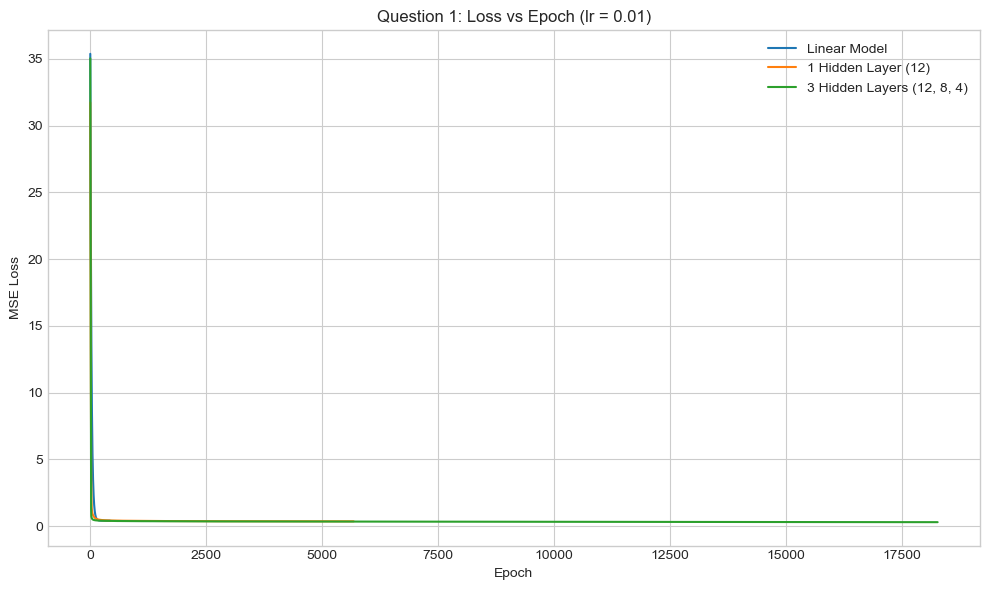

In [44]:
plt.figure(figsize=(10, 6))
for model_name, result in q1_results.items():
    epochs = np.arange(1, len(result.loss_history) + 1)
    plt.plot(epochs, result.loss_history, label=model_name)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Question 1: Loss vs Epoch (lr = 0.01)')
plt.legend()
plt.tight_layout()
plt.show()


### Question 1 Discussion

Parameter counts:
- Linear model: 12
- Single-hidden-layer model (12): 157
- Three-hidden-layer model (12, 8, 4): 289

**(a) Did all three models converge to the same minimum loss?**
No. They converged to different minimum losses. In this run, the best minimum came from **3 Hidden Layers (12, 8, 4)** with final loss **0.306554**.

My interpretation: the deeper models have more parameters and ReLU nonlinearities, so they can fit more complex patterns in the wine features. The linear model only learns one global linear relationship, which limits how low its loss can go.

**(b) Did the number of epochs to converge differ?**
Yes. It varied a lot. The slowest was **3 Hidden Layers (12, 8, 4)** at **18276** epochs.

So in this experiment, higher-capacity models reached lower loss, but they usually needed more epochs before the loss stabilized to 4 decimal places.


## Question 2

Use the 3-hidden-layer architecture with hidden sizes **(16, 8, 4)** and train with learning rates:

`0.00001, 0.0001, 0.001, 0.01, 0.1`

Plot all loss curves on the same axis and discuss minimum loss and convergence speed.


In [46]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
q2_results = {}

for lr in learning_rates:
    SeedManager.set_seed(CLASS_SEED)
    model = ThreeHiddenLayerNetwork(input_dim=input_dim, hidden_dims=(16, 8, 4))
    lr_config = TrainConfig(
        learning_rate=lr,
        max_epochs=20000,
        convergence_window=50,
        convergence_decimals=4,
    )
    q2_results[lr] = runner.train_model(
        model=model,
        features=features,
        targets=targets,
        config=lr_config,
        model_name=f'LR={lr}',
    )

q2_table = pd.DataFrame(
    {
        'Learning Rate': list(q2_results.keys()),
        'Final Loss': [q2_results[lr].final_loss for lr in q2_results],
        'Epochs Run': [q2_results[lr].epochs_run for lr in q2_results],
        'Converged': [q2_results[lr].converged for lr in q2_results],
    }
)
q2_table


,Learning Rate,Final Loss,Epochs Run,Converged
0,0.00001,1.741896,20000,False
1,0.00010,0.451933,20000,False
2,0.00100,0.381052,13398,True
3,0.01000,0.294454,14597,True
4,0.10000,0.234008,20000,False


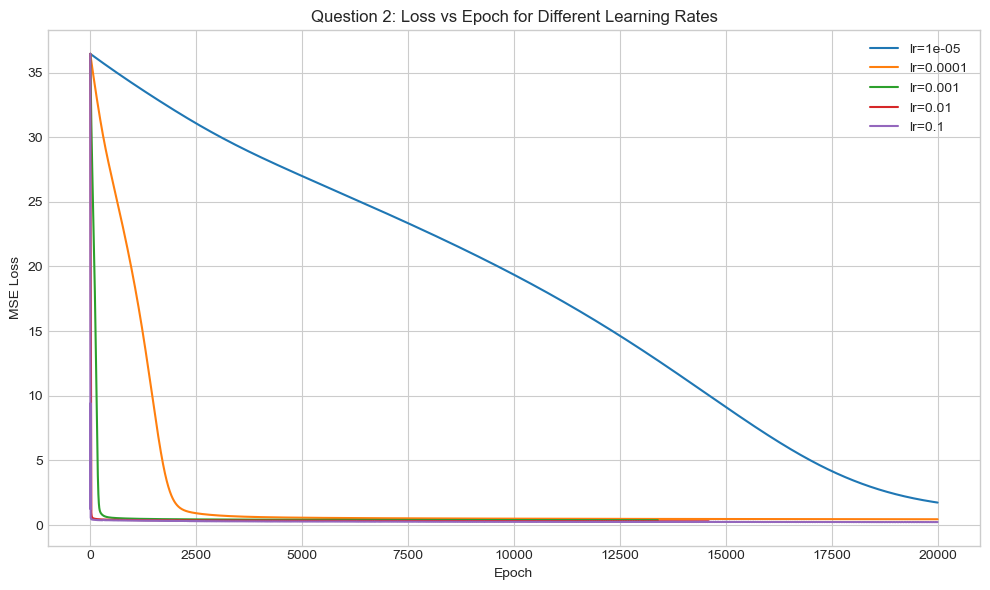

In [47]:
plt.figure(figsize=(10, 6))
for lr, result in q2_results.items():
    epochs = np.arange(1, len(result.loss_history) + 1)
    plt.plot(epochs, result.loss_history, label=f'lr={lr}')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Question 2: Loss vs Epoch for Different Learning Rates')
plt.legend()
plt.tight_layout()
plt.show()


### Question 2 Discussion

**(a) Impact of learning rate on minimum loss**
Learning rate changed the final loss a lot. The lowest final loss here was with **lr=0.01**, which ended at **0.294454**.

Very small rates (`1e-5`, `1e-4`) moved too slowly, so they stayed at relatively high loss even after many epochs.

**(b) Impact of learning rate on epochs to converge**
The fastest convergence by epoch count was **lr=0.001** at **13398** epochs.

From the curves, I see a practical pattern: small rates are stable but slow, medium rates are usually the best balance, and very large rates can keep bouncing near the minimum and fail the strict convergence test.


## Question 3

Randomly split the dataset in half and retrain the three Question 1 models.

Then compare whether reducing data quantity changes converged loss values and whether all models are affected similarly.


In [49]:
SeedManager.set_seed(CLASS_SEED)
(full_X, full_y) = (features, targets)
(half_X, half_y), _ = dataset.split_half(features=features, targets=targets, seed=CLASS_SEED)

q3_results_full = {}
q3_results_half = {}

for model_name, model_factory in q1_models.items():
    SeedManager.set_seed(CLASS_SEED)
    model_full = model_factory()
    q3_results_full[model_name] = runner.train_model(
        model=model_full,
        features=full_X,
        targets=full_y,
        config=base_config,
        model_name=model_name,
    )

    SeedManager.set_seed(CLASS_SEED)
    model_half = model_factory()
    q3_results_half[model_name] = runner.train_model(
        model=model_half,
        features=half_X,
        targets=half_y,
        config=base_config,
        model_name=model_name,
    )

q3_table = pd.DataFrame(
    {
        'Model': list(q1_models.keys()),
        'Final Loss (Full Data)': [q3_results_full[name].final_loss for name in q1_models],
        'Final Loss (Half Data)': [q3_results_half[name].final_loss for name in q1_models],
        'Epochs (Full Data)': [q3_results_full[name].epochs_run for name in q1_models],
        'Epochs (Half Data)': [q3_results_half[name].epochs_run for name in q1_models],
    }
)
q3_table


,Model,Final Loss (Full Data),Final Loss (Half Data),Epochs (Full Data),Epochs (Half Data)
0,Linear Model,0.416807,0.417460,426,650
1,1 Hidden Layer (12),0.348251,0.322051,9621,11045
2,"3 Hidden Layers (12, 8, 4)",0.315052,0.264554,12796,14720


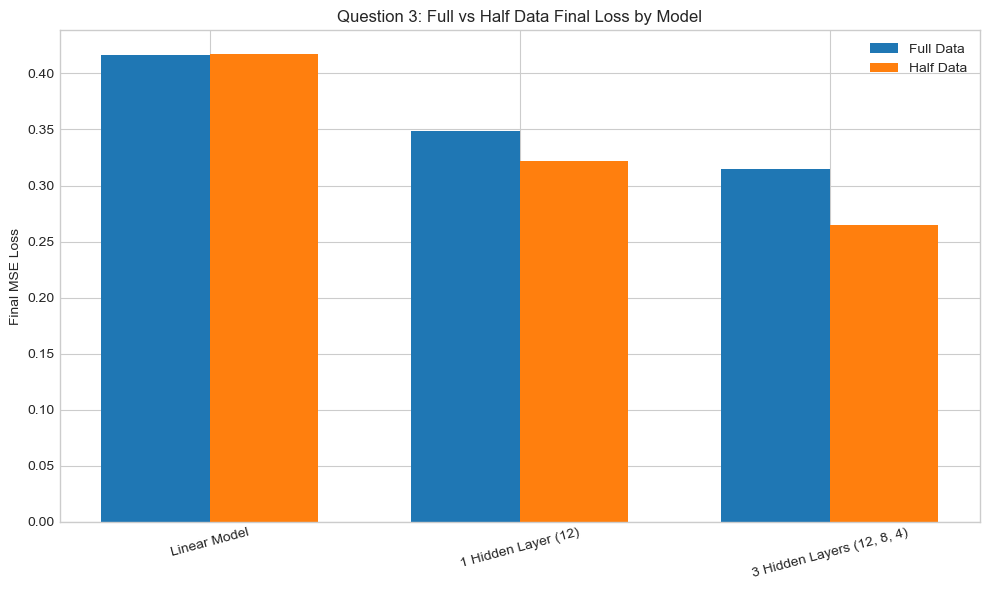

In [50]:
model_names = list(q1_models.keys())
full_losses = [q3_results_full[name].final_loss for name in model_names]
half_losses = [q3_results_half[name].final_loss for name in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width / 2, full_losses, width=width, label='Full Data')
plt.bar(x + width / 2, half_losses, width=width, label='Half Data')
plt.xticks(x, model_names, rotation=15)
plt.ylabel('Final MSE Loss')
plt.title('Question 3: Full vs Half Data Final Loss by Model')
plt.legend()
plt.tight_layout()
plt.show()


### Question 3 Discussion

**Did data quantity change converged loss values?**
Yes. The converged losses changed when I trained on only half the data.

**Were models affected similarly?**
Not exactly. The effect size differed by architecture:
- Least affected model: **Linear Model** (loss change +0.000653)
- Most affected model: **3 Hidden Layers (12, 8, 4)** (loss change -0.042000)

My hypothesis from these results: when data is reduced, higher-capacity networks can fit the smaller training set more aggressively, so training loss can drop more. That does not automatically mean better generalization; it can also indicate easier overfitting.


## Final Check

This notebook includes:

- All three required questions
- OOP PyTorch model/training implementation
- Loss-vs-epoch plots with combined curves
- Parameter count reporting
- Text-based discussions for each question

Run all cells top-to-bottom before submitting.
